In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re

# config plots
plt.style.use('ggplot')
%matplotlib inline

# sanity check imports
print("libraries loaded successfully")

libraries loaded successfully


In [2]:
# load train data
df = pd.read_csv('../data/processed/train.csv')

# sanity check shape
# should be (3448, ...) rows
print(f"train shape: {df.shape}")
print("columns:", df.columns.tolist())

# check for missing values in critical columns
# text columns shouldn't have NaNs after cleaning
print(df[['clean_question', 'clean_answer', 'clarity_label', 'evasion_label']].isna().sum())

train shape: (3448, 22)
columns: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label', 'clean_question', 'clean_answer']
clean_question    0
clean_answer      1
clarity_label     0
evasion_label     0
dtype: int64


C:\Users\imada\AppData\Local\Temp\ipykernel_6244\3858019254.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clarity_counts.index, y=clarity_counts.values, ax=axes[0], palette='viridis')
C:\Users\imada\AppData\Local\Temp\ipykernel_6244\3858019254.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=evasion_counts.index, y=evasion_counts.values, ax=axes[1], palette='rocket')


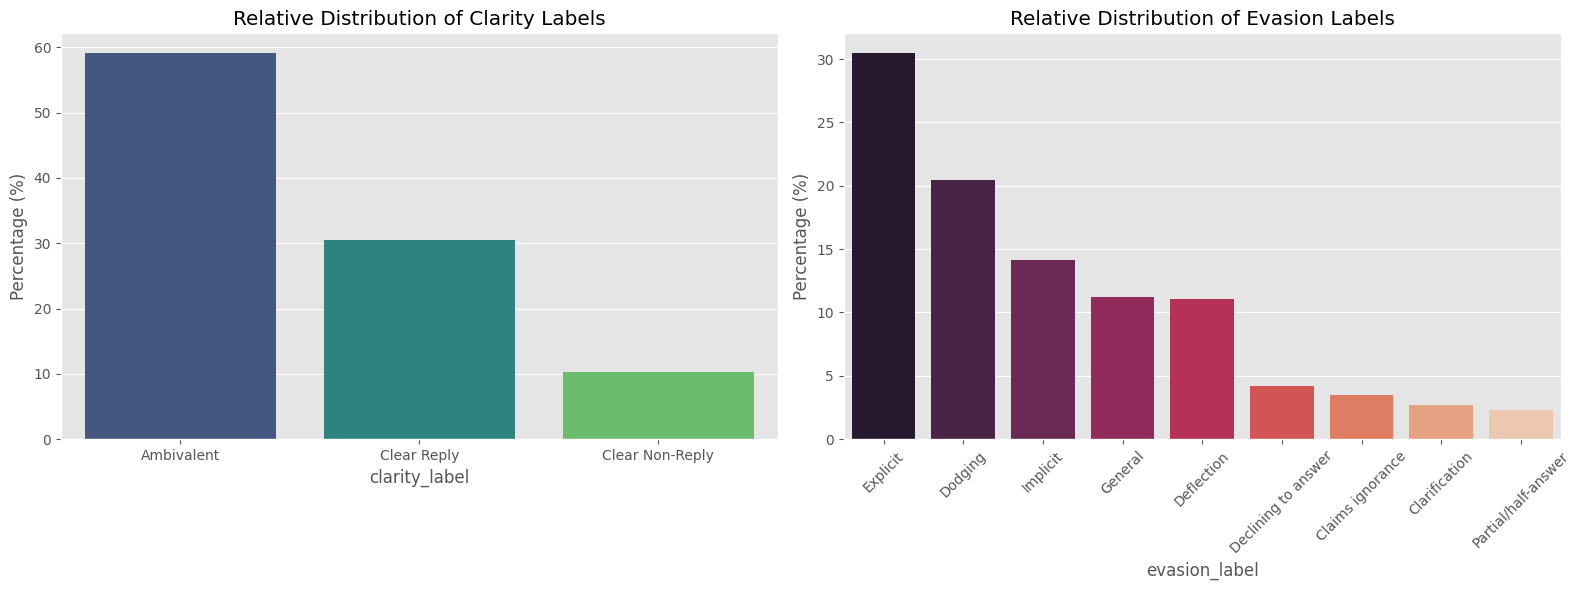

Clarity Distribution:
 clarity_label
Ambivalent         59.164733
Clear Reply        30.510441
Clear Non-Reply    10.324826
Name: proportion, dtype: float64


In [3]:
# setup figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- plot 1: clarity distribution ---
# calc percentages
clarity_counts = df['clarity_label'].value_counts(normalize=True) * 100
sns.barplot(x=clarity_counts.index, y=clarity_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Relative Distribution of Clarity Labels')
axes[0].set_ylabel('Percentage (%)')

# --- plot 2: evasion distribution ---
# calc percentages
evasion_counts = df['evasion_label'].value_counts(normalize=True) * 100
sns.barplot(x=evasion_counts.index, y=evasion_counts.values, ax=axes[1], palette='rocket')
axes[1].set_title('Relative Distribution of Evasion Labels')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# print exact numbers for report
print("Clarity Distribution:\n", clarity_counts)

Mean word count (raw): 293.57
Mean word count (no stop words): 137.62


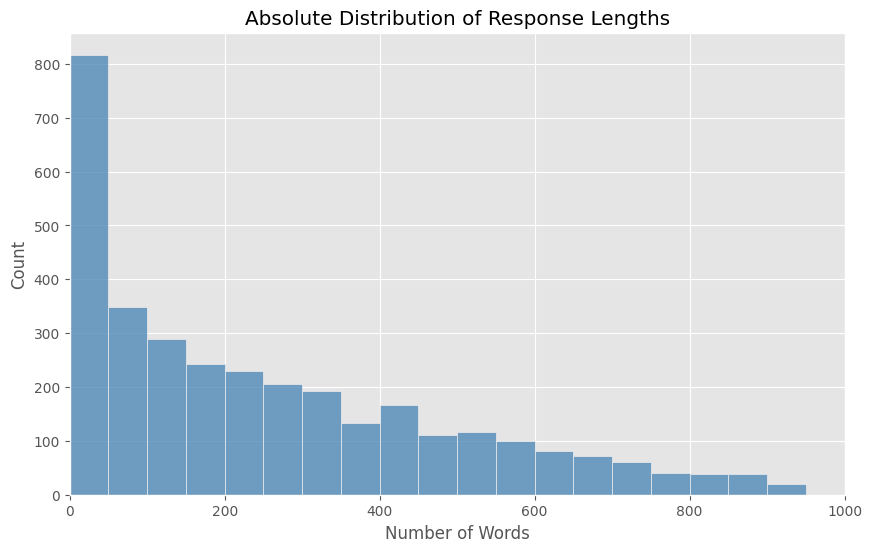

In [4]:
# helper to count words
def get_word_len(text):
    if not isinstance(text, str): return 0
    return len(text.split())

# calc lengths on raw 'interview_answer' (not cleaned) for accuracy
df['answer_len'] = df['interview_answer'].apply(get_word_len)

# calc lengths without stopwords (using 'clean_answer')
stop_words = set(stopwords.words('english'))
df['clean_answer_len'] = df['clean_answer'].apply(lambda x: len([w for w in str(x).split() if w not in stop_words]))

# print stats
print(f"Mean word count (raw): {df['answer_len'].mean():.2f}")
print(f"Mean word count (no stop words): {df['clean_answer_len'].mean():.2f}")

# plot histogram (Figure 2)
plt.figure(figsize=(10, 6))
sns.histplot(df['answer_len'], bins=range(0, 1000, 50), kde=False, color='steelblue')
plt.title('Absolute Distribution of Response Lengths')
plt.xlabel('Number of Words')
plt.xlim(0, 1000) # cap at 1000 for visibility
plt.show()

In [5]:
# build vocab from clean answers
all_words = " ".join(df['clean_answer'].astype(str)).split()
unique_words = set(all_words)

print(f"Vocabulary Size (unique words): {len(unique_words)}")

Vocabulary Size (unique words): 21056


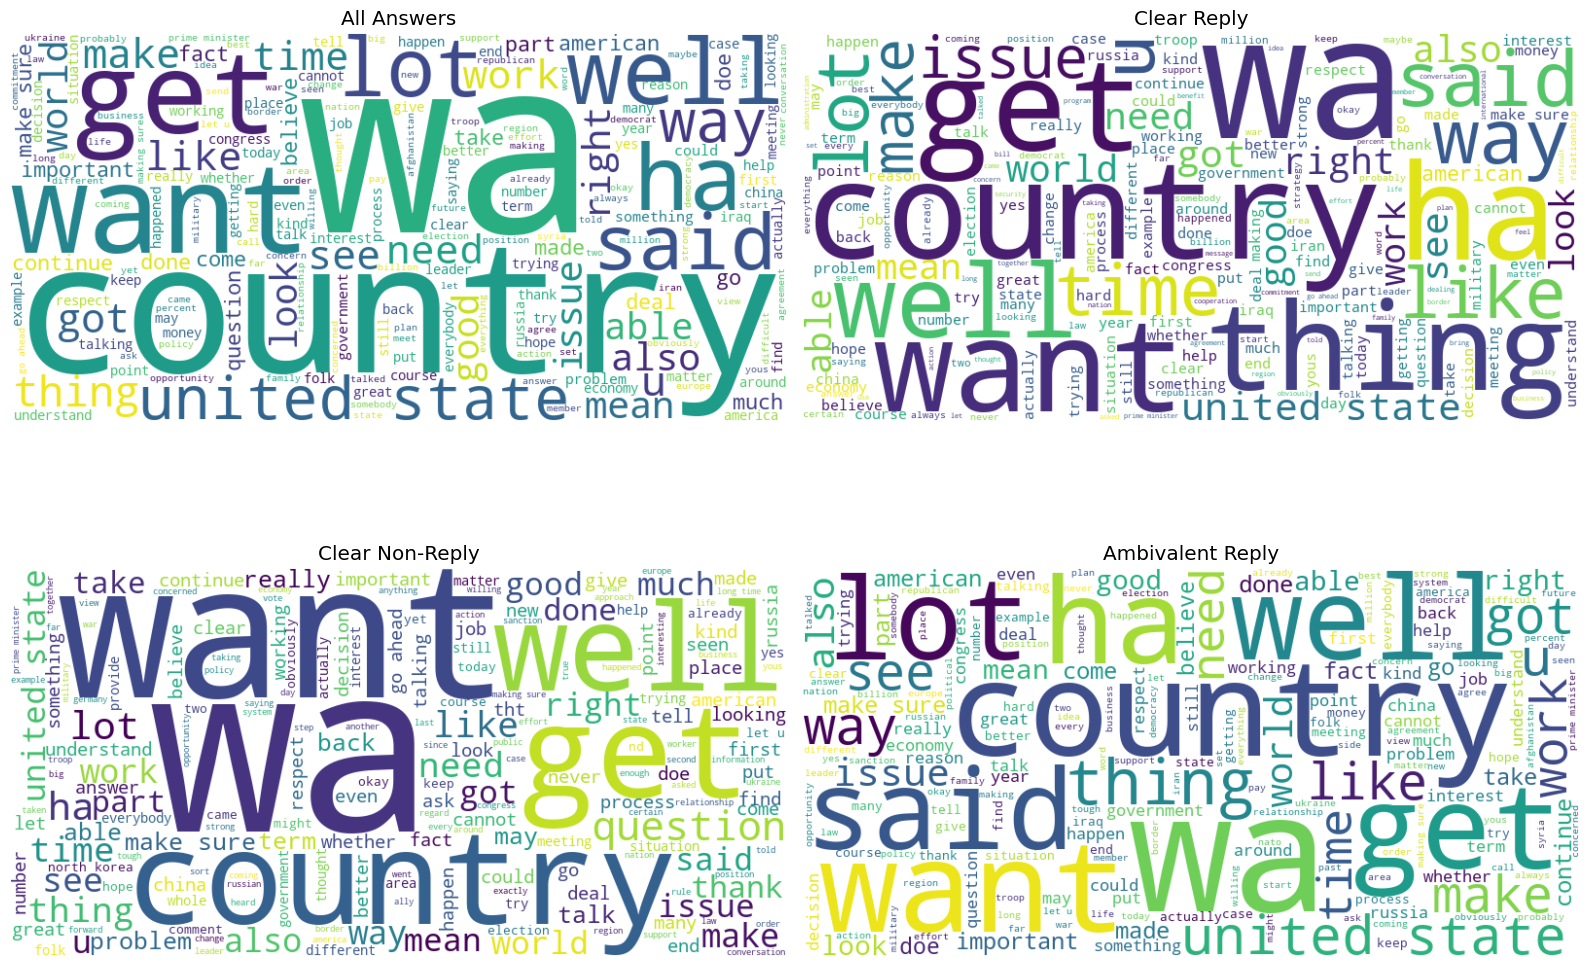

In [6]:
def plot_wordcloud(text, title, ax):
    # remove common political stopwords to make it meaningful
    custom_stops = stop_words.union({'president', 'think', 'going', 'people', 'know', 'would', 'one', 'us', 'say'})
    
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stops).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title)
    ax.axis('off')

# setup grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. All Answers
all_text = " ".join(df['clean_answer'].astype(str))
plot_wordcloud(all_text, "All Answers", axes[0, 0])

# 2. Clear Reply
clear_text = " ".join(df[df['clarity_label'] == 'Clear Reply']['clean_answer'].astype(str))
plot_wordcloud(clear_text, "Clear Reply", axes[0, 1])

# 3. Clear Non-Reply
non_reply_text = " ".join(df[df['clarity_label'] == 'Clear Non-Reply']['clean_answer'].astype(str))
plot_wordcloud(non_reply_text, "Clear Non-Reply", axes[1, 0])

# 4. Ambivalent
ambivalent_text = " ".join(df[df['clarity_label'] == 'Ambivalent']['clean_answer'].astype(str))
plot_wordcloud(ambivalent_text, "Ambivalent Reply", axes[1, 1])

plt.tight_layout()
plt.show()